# Paper reproduction — SyntheticMarket-GAN (WGAN-GP on AAPL)

This notebook reproduces the validation figures and headline numbers from the blog post
[*WGAN-GP on AAPL: when PCA looks fine but step-by-step volatility is 4× off*](https://nicotimoneda.substack.com/p/wgan-gp-on-aapl-when-pca-looks-fine).

It **imports the `syntheticmarket` package** (no logic is duplicated here) and loads the
published generator weights `models/generator_wgan.pth`. Expected results:

| Metric | Value |
|---|---|
| PCA PC1 explained variance | ~98.8% |
| Step-to-step std (real) | ~0.009 |
| Step-to-step std (synthetic) | ~0.039 |
| Ratio | ~4.3× |

In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from syntheticmarket.data.loader import SEQ_LEN, load_price_windows
from syntheticmarket.models.generator import NOISE_DIM, Generator
from syntheticmarket.evaluation.dimreduction import pca_analysis, tsne_analysis
from syntheticmarket.evaluation.metrics import summary_metrics
from syntheticmarket.training.trainer import set_seed

SEED = 42
N = 500
WEIGHTS = Path("..") / "models" / "generator_wgan.pth"
set_seed(SEED)

In [2]:
# Load the published generator weights and draw real + synthetic windows.
generator = Generator()
generator.load_state_dict(torch.load(WEIGHTS, map_location="cpu"))
generator.eval()

windows, _ = load_price_windows()  # downloads AAPL via yfinance, scales, windows
rng = np.random.default_rng(SEED)
real = windows[rng.choice(windows.shape[0], N, replace=False)]

with torch.no_grad():
    z = torch.randn(N, SEQ_LEN, NOISE_DIM)
    synthetic = generator(z).numpy()

print(real.shape, synthetic.shape)

(500, 24, 1) (500, 24, 1)


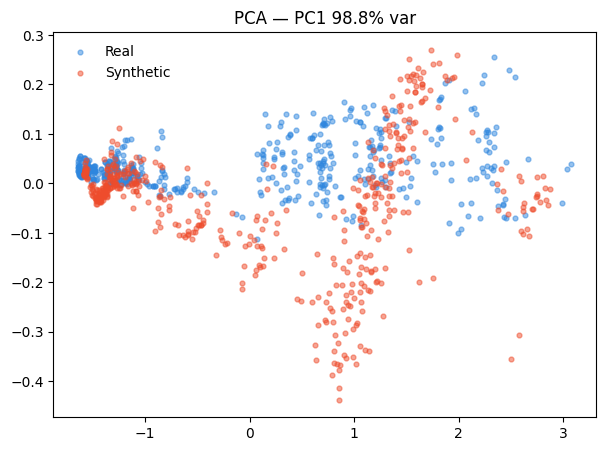

PC1 explained variance: 98.8%


In [3]:
# PCA: marginal distribution overlap (PC1 captures the price level).
combined = np.concatenate([real, synthetic], axis=0)
pca_coords, explained = pca_analysis(combined)

plt.figure(figsize=(7, 5))
plt.scatter(pca_coords[:N, 0], pca_coords[:N, 1], s=12, c="#2E86DE", alpha=0.5, label="Real")
plt.scatter(pca_coords[N:, 0], pca_coords[N:, 1], s=12, c="#EE4C2C", alpha=0.5, label="Synthetic")
plt.title(f"PCA — PC1 {explained[0] * 100:.1f}% var")
plt.legend(frameon=False)
plt.show()

print(f"PC1 explained variance: {explained[0] * 100:.1f}%")

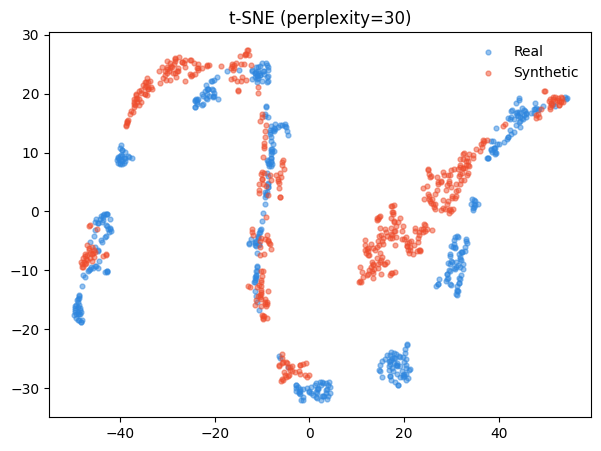

In [4]:
# t-SNE: real and synthetic occupy adjacent ridges of the same manifold (no mode collapse).
tsne_coords = tsne_analysis(combined, seed=SEED)

plt.figure(figsize=(7, 5))
plt.scatter(tsne_coords[:N, 0], tsne_coords[:N, 1], s=12, c="#2E86DE", alpha=0.5, label="Real")
plt.scatter(tsne_coords[N:, 0], tsne_coords[N:, 1], s=12, c="#EE4C2C", alpha=0.5, label="Synthetic")
plt.title("t-SNE (perplexity=30)")
plt.legend(frameon=False)
plt.show()

In [5]:
# The key finding: step-to-step volatility is ~4x too high in synthetic data.
metrics = summary_metrics(real, synthetic)
for key, value in metrics.items():
    print(f"{key:32s} {value:.4f}")

step_to_step_std_real            0.0091
step_to_step_std_synthetic       0.0388
step_to_step_ratio               4.2492
